# 2D Binary Pattern Matching — Comprehensive Testing Notebook
Tests three scenarios:
1. **Random Growth** — ablation over pattern & text sizes, binary random arrays
2. **Real-World QR Codes** — search for a Tetrimino (L-shape) in 100 QR code images
3. **Contrived Cases** — all-1s text with a hidden 3×3 block of 0s near the end

Primary metric: **equality-operation count**. Wall-clock time is recorded as a secondary metric.

In [14]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image

from algos.naive import naive_search
from algos.rabin_karp import rabin_karp_search, vectorized_rabin_karp
from algos.greedy import greedy_kmp_search, greedy_bm_search
from algos.bird import bird_bm, bird_kmp

ALGORITHMS = {
    'Naive':               naive_search,
    'Rabin-Karp':          rabin_karp_search,
    'Vectorized RK':       vectorized_rabin_karp,
    'Greedy KMP':          greedy_kmp_search,
    'Greedy BM':           greedy_bm_search,
    'Bird-KMP':            bird_kmp,
    'Bird-BM':             bird_bm,
}

print('All imports OK.')
print('Algorithms registered:', list(ALGORITHMS.keys()))

All imports OK.
Algorithms registered: ['Naive', 'Rabin-Karp', 'Vectorized RK', 'Greedy KMP', 'Greedy BM', 'Bird-KMP', 'Bird-BM']


---
## Helper Utilities

In [15]:
def make_donut(size: int) -> np.ndarray:
    """Square binary array of 0s wrapped by a border of 1s (donut shape)."""
    arr = np.zeros((size, size), dtype=np.int8)
    arr[0, :]  = 1
    arr[-1, :] = 1
    arr[:, 0]  = 1
    arr[:, -1] = 1
    return arr

def make_random_binary(size: int, rng: np.random.Generator) -> np.ndarray:
    """Random binary array using donut structure (0-centre, 1-border)."""
    return make_donut(size)

def make_random_pattern(pat_size: int, rng: np.random.Generator) -> np.ndarray:
    """Random binary pattern."""
    return rng.integers(0, 2, size=(pat_size, pat_size), dtype=np.int8)

def run_all(text: np.ndarray, pattern: np.ndarray):
    """Run every algorithm on (text, pattern). Returns dict of {name: (comp_count, result, wall_s)}."""
    results = {}
    for name, fn in ALGORITHMS.items():
        t0 = time.perf_counter()
        try:
            comp, pos = fn(text.copy(), pattern.copy())
        except Exception as e:
            comp, pos = -1, f'ERROR: {e}'
        wall = time.perf_counter() - t0
        results[name] = (comp, pos, wall)
    return results

def results_to_rows(results: dict, extra: dict) -> list:
    """Flatten run_all output into a list of dicts suitable for a DataFrame."""
    rows = []
    for algo, (comp, pos, wall) in results.items():
        row = {'algorithm': algo, 'comparisons': comp, 'match': pos, 'wall_sec': round(wall, 6)}
        row.update(extra)
        rows.append(row)
    return rows

print('Utilities defined.')

Utilities defined.


In [16]:
make_random_pattern(100, rng=np.random.default_rng(2))
make_donut(3)

res = run_all(make_random_pattern(100, rng=np.random.default_rng(2)), make_donut(3))
results_to_rows(res, {'pattern_size': 3, 'text_size': 100, 'seed': 2})


[{'algorithm': 'Naive',
  'comparisons': 411,
  'match': (2, 6),
  'wall_sec': 0.000739,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Rabin-Karp',
  'comparisons': 600,
  'match': (2, 6),
  'wall_sec': 0.010046,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Vectorized RK',
  'comparisons': 212,
  'match': (2, 6),
  'wall_sec': 0.004223,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Greedy KMP',
  'comparisons': 529,
  'match': (2, 6),
  'wall_sec': 0.000417,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Greedy BM',
  'comparisons': 211,
  'match': (2, 6),
  'wall_sec': 0.000282,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Bird-KMP',
  'comparisons': 236,
  'match': (2, 6),
  'wall_sec': 0.00071,
  'pattern_size': 3,
  'text_size': 100,
  'seed': 2},
 {'algorithm': 'Bird-BM',
  'comparisons': 89,
  'match': (2, 6),
  'wall_sec': 0.00042,
  'pattern_size': 3,
  

---
## Part 1 — Random Growth Ablation

In [17]:
PATTERN_SIZES = [3, 5, 7, 13]
TEXT_SIZES    = [25, 50, 100, 200, 500, 1000, 2000]
SEEDS         = [42, 7, 123, 2024, 999]

random_rows = []

total = len(PATTERN_SIZES) * len(TEXT_SIZES) * len(SEEDS)
done  = 0

for pat_size in PATTERN_SIZES:
    for txt_size in TEXT_SIZES:
        if pat_size >= txt_size:
            done += len(SEEDS)
            continue                # skip invalid combos
        for seed in SEEDS:
            rng  = np.random.default_rng(seed)
            text    = make_donut(txt_size)
            pattern = make_random_pattern(pat_size, rng)

            res = run_all(text, pattern)
            extra = {'pattern_size': pat_size, 'text_size': txt_size, 'seed': seed}
            random_rows.extend(results_to_rows(res, extra))

            done += 1
            if done % 20 == 0:
                print(f'  {done}/{total} combos done...')

df_random = pd.DataFrame(random_rows)
df_random.to_csv('results_random.csv', index=False)
print(f'\nRandom ablation complete. Shape: {df_random.shape}')
df_random.head(10)

  20/140 combos done...
  40/140 combos done...
  60/140 combos done...
  80/140 combos done...
  100/140 combos done...
  120/140 combos done...
  140/140 combos done...

Random ablation complete. Shape: (980, 7)


,algorithm,comparisons,match,wall_sec,pattern_size,text_size,seed
0,Naive,596,None,0.001293,3,25,42
1,Rabin-Karp,529,None,0.001449,3,25,42
2,Vectorized RK,529,None,0.001350,3,25,42
3,Greedy KMP,1129,None,0.000864,3,25,42
4,Greedy BM,596,None,0.000569,3,25,42
5,Bird-KMP,600,None,0.001579,3,25,42
6,Bird-BM,189,None,0.001020,3,25,42
7,Naive,596,None,0.000909,3,25,7
8,Rabin-Karp,529,None,0.000998,3,25,7
9,Vectorized RK,529,None,0.000848,3,25,7


### 1a — Comparisons vs Text Size (per Pattern Size)

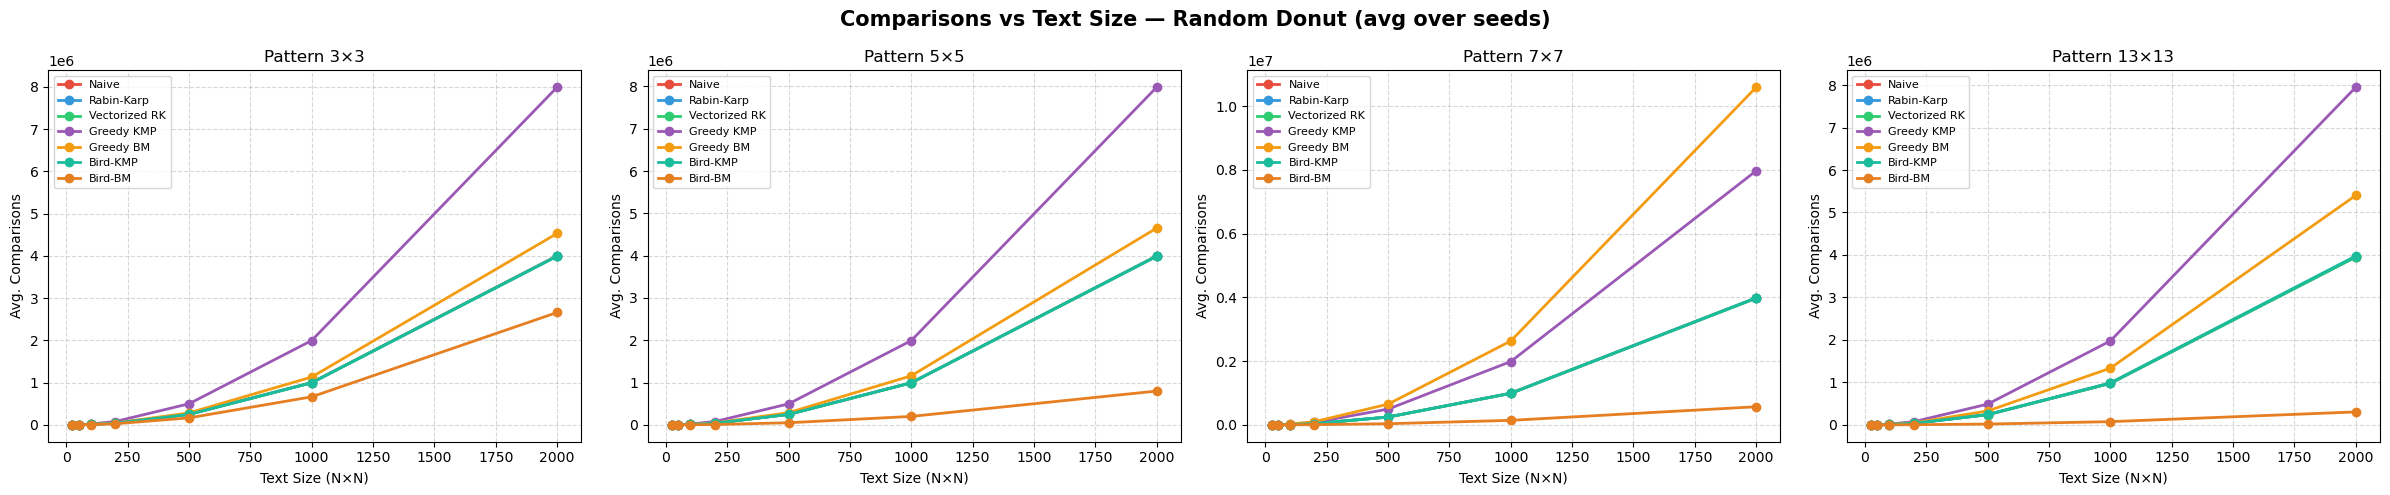

Saved: random_comparisons_vs_textsize.png


In [18]:
algo_colors = {
    'Naive':         '#e74c3c',
    'Rabin-Karp':    '#3498db',
    'Vectorized RK': '#2ecc71',
    'Greedy KMP':    '#9b59b6',
    'Greedy BM':     '#f39c12',
    'Bird-KMP':      '#1abc9c',
    'Bird-BM':       '#e67e22',
}

# Average over seeds
agg = (df_random
       .groupby(['algorithm', 'pattern_size', 'text_size'])['comparisons']
       .mean()
       .reset_index())

fig, axes = plt.subplots(1, len(PATTERN_SIZES), figsize=(6 * len(PATTERN_SIZES), 5), sharey=False)
fig.suptitle('Comparisons vs Text Size — Random Donut (avg over seeds)', fontsize=15, fontweight='bold')

for ax, pat in zip(axes, PATTERN_SIZES):
    sub = agg[agg['pattern_size'] == pat]
    for algo in ALGORITHMS:
        d = sub[sub['algorithm'] == algo].sort_values('text_size')
        if d.empty:
            continue
        ax.plot(d['text_size'], d['comparisons'],
                marker='o', label=algo, color=algo_colors[algo], linewidth=2)
    ax.set_title(f'Pattern {pat}×{pat}', fontsize=12)
    ax.set_xlabel('Text Size (N×N)')
    ax.set_ylabel('Avg. Comparisons')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('random_comparisons_vs_textsize.png', dpi=150)
plt.show()
print('Saved: random_comparisons_vs_textsize.png')

### 1b — Comparisons vs Pattern Size (per Text Size)

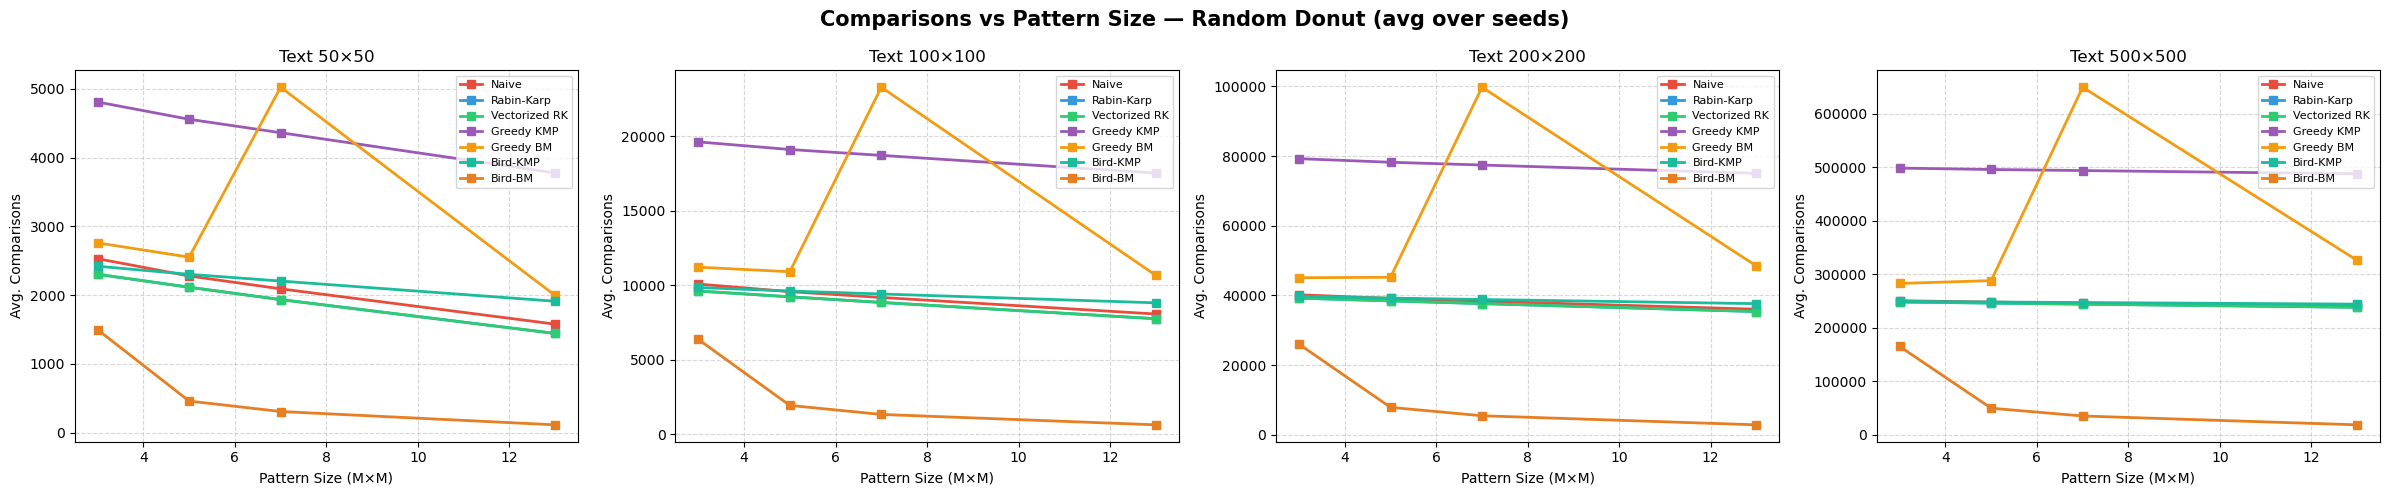

Saved: random_comparisons_vs_patsize.png


In [19]:
plot_text_sizes = [50, 100, 200, 500]

fig, axes = plt.subplots(1, len(plot_text_sizes),
                         figsize=(6 * len(plot_text_sizes), 5), sharey=False)
fig.suptitle('Comparisons vs Pattern Size — Random Donut (avg over seeds)', fontsize=15, fontweight='bold')

for ax, txt in zip(axes, plot_text_sizes):
    sub = agg[agg['text_size'] == txt]
    for algo in ALGORITHMS:
        d = sub[sub['algorithm'] == algo].sort_values('pattern_size')
        if d.empty:
            continue
        ax.plot(d['pattern_size'], d['comparisons'],
                marker='s', label=algo, color=algo_colors[algo], linewidth=2)
    ax.set_title(f'Text {txt}×{txt}', fontsize=12)
    ax.set_xlabel('Pattern Size (M×M)')
    ax.set_ylabel('Avg. Comparisons')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('random_comparisons_vs_patsize.png', dpi=150)
plt.show()
print('Saved: random_comparisons_vs_patsize.png')

### 1c — Wall-Clock Time Overview (Random)

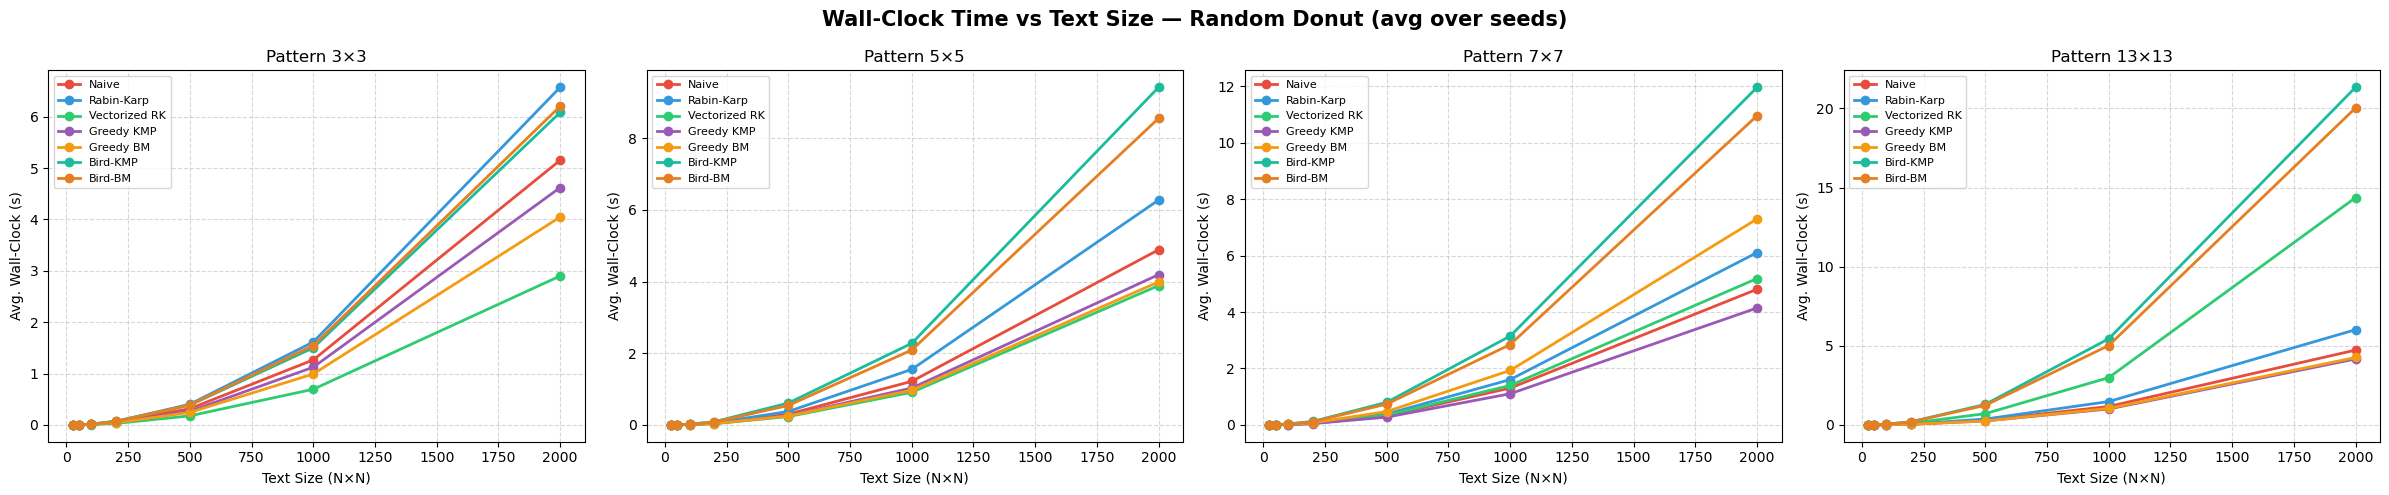

In [20]:
agg_time = (df_random
            .groupby(['algorithm', 'pattern_size', 'text_size'])['wall_sec']
            .mean()
            .reset_index())

fig, axes = plt.subplots(1, len(PATTERN_SIZES), figsize=(6 * len(PATTERN_SIZES), 5), sharey=False)
fig.suptitle('Wall-Clock Time vs Text Size — Random Donut (avg over seeds)', fontsize=15, fontweight='bold')

for ax, pat in zip(axes, PATTERN_SIZES):
    sub = agg_time[agg_time['pattern_size'] == pat]
    for algo in ALGORITHMS:
        d = sub[sub['algorithm'] == algo].sort_values('text_size')
        if d.empty:
            continue
        ax.plot(d['text_size'], d['wall_sec'],
                marker='o', label=algo, color=algo_colors[algo], linewidth=2)
    ax.set_title(f'Pattern {pat}×{pat}', fontsize=12)
    ax.set_xlabel('Text Size (N×N)')
    ax.set_ylabel('Avg. Wall-Clock (s)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('random_wallclock.png', dpi=150)
plt.show()

---
## Part 2 — Real-World QR Codes
Search for a Tetrimino (L/J shape) in each QR code image:
```
 #
###
```

In [21]:
DONUT = np.array([
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1]
], dtype=np.int8)

print('Reverse Donut pattern:')
print(DONUT)

QR_DIR = Path('qr')
qr_files = sorted(QR_DIR.glob('*.png'))[:100]   # at most 100
print(f'\nFound {len(qr_files)} QR PNG files in ./{QR_DIR}/')

Reverse Donut pattern:
[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 1 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]

Found 60 QR PNG files in ./qr/


In [22]:
def png_to_binary(path: Path, threshold: int = 128) -> np.ndarray:
    """Load a PNG, convert to grayscale, threshold to binary int8 array.
    Dark pixels (< threshold) → 1, light → 0 (standard QR convention).
    """
    img = Image.open(path).convert('L')   # grayscale
    arr = np.array(img)
    binary = (arr < threshold).astype(np.int8)  # 1 = dark
    return binary

# Quick sanity check on first QR
if qr_files:
    sample = png_to_binary(qr_files[0])
    np.set_printoptions(threshold=np.inf) # or np.inf
    print(f'Sample QR shape: {sample.shape}, unique values: {np.unique(sample)}')
    print(rabin_karp_search(sample[::10, ::10], DONUT))
else:
    print('WARNING: No QR files found — skipping QR section.')

Sample QR shape: (370, 370), unique values: [0 1]
(910, (26, 26))


In [23]:
qr_rows = []

for idx, qr_path in enumerate(qr_files):
    try:
        text_qr = png_to_binary(qr_path)
        text_qr = text_qr[::10, ::10]
    except Exception as e:
        print(f'  Could not load {qr_path.name}: {e}')
        continue

    res = run_all(text_qr, DONUT)
    extra = {'qr_file': qr_path.name,
             'qr_idx':  idx,
             'text_h':  text_qr.shape[0],
             'text_w':  text_qr.shape[1]}
    qr_rows.extend(results_to_rows(res, extra))

    if (idx + 1) % 10 == 0:
        print(f'  {idx+1}/{len(qr_files)} QR codes processed...')

df_qr = pd.DataFrame(qr_rows)
df_qr.to_csv('results_qr.csv', index=False)
print(f'\nQR section complete. Shape: {df_qr.shape}')
df_qr.head(10)

  10/60 QR codes processed...
  20/60 QR codes processed...
  30/60 QR codes processed...
  40/60 QR codes processed...
  50/60 QR codes processed...
  60/60 QR codes processed...

QR section complete. Shape: (420, 8)


,algorithm,comparisons,match,wall_sec,qr_file,qr_idx,text_h,text_w
0,Naive,1781,"(26, 26)",0.003605,benign_0.png,0,37,37
1,Rabin-Karp,910,"(26, 26)",0.003964,benign_0.png,0,37,37
2,Vectorized RK,910,"(26, 26)",0.002611,benign_0.png,0,37,37
3,Greedy KMP,2434,"(26, 26)",0.001703,benign_0.png,0,37,37
4,Greedy BM,669,"(26, 26)",0.000582,benign_0.png,0,37,37
5,Bird-KMP,1039,"(26, 26)",0.003852,benign_0.png,0,37,37
6,Bird-BM,215,"(26, 26)",0.003741,benign_0.png,0,37,37
7,Naive,1733,"(26, 26)",0.002615,benign_1.png,1,37,37
8,Rabin-Karp,910,"(26, 26)",0.002786,benign_1.png,1,37,37
9,Vectorized RK,910,"(26, 26)",0.001265,benign_1.png,1,37,37


### 2a — Average Comparisons per Algorithm Across All QR Codes

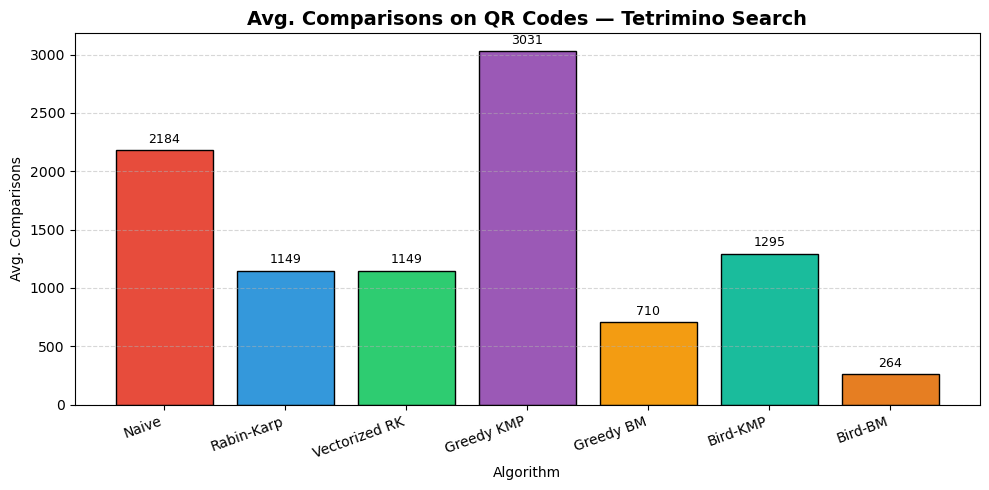

Saved: qr_avg_comparisons.png


In [24]:
if not df_qr.empty:
    agg_qr = (df_qr.groupby('algorithm')['comparisons']
              .mean()
              .reindex(list(ALGORITHMS.keys()))
              .reset_index())
    agg_qr.columns = ['algorithm', 'avg_comparisons']

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [algo_colors[a] for a in agg_qr['algorithm']]
    bars = ax.bar(agg_qr['algorithm'], agg_qr['avg_comparisons'], color=colors, edgecolor='black')
    ax.set_title('Avg. Comparisons on QR Codes — Tetrimino Search', fontsize=14, fontweight='bold')
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Avg. Comparisons')
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
    plt.xticks(rotation=20, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('qr_avg_comparisons.png', dpi=150)
    plt.show()
    print('Saved: qr_avg_comparisons.png')
else:
    print('No QR data to plot.')

### 2b — Per-QR-Code Comparisons (all algorithms)

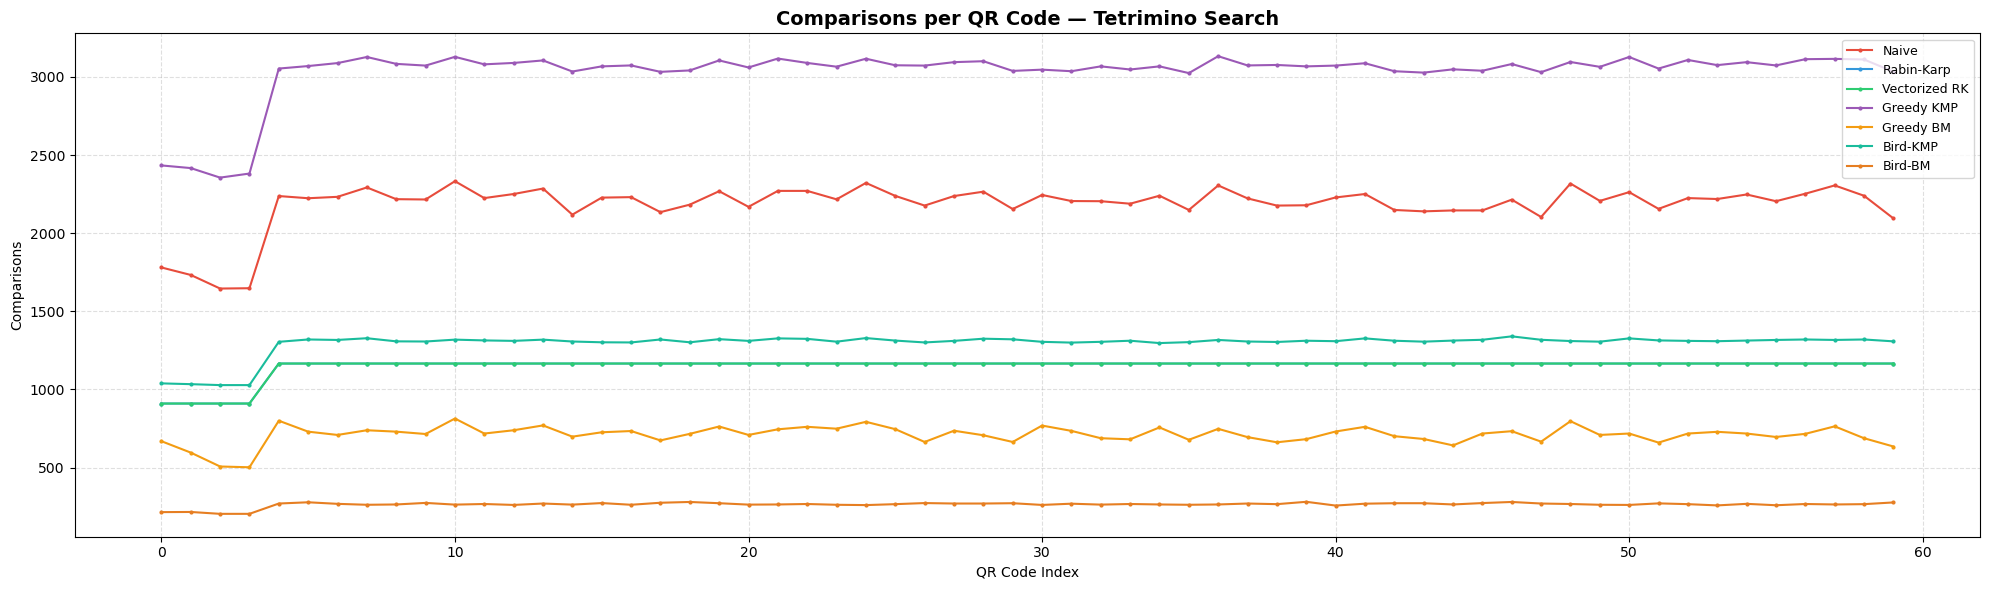

In [25]:
if not df_qr.empty:
    fig, ax = plt.subplots(figsize=(max(12, len(qr_files) // 3), 6))

    for algo in ALGORITHMS:
        sub = df_qr[df_qr['algorithm'] == algo].sort_values('qr_idx')
        ax.plot(sub['qr_idx'], sub['comparisons'],
                label=algo, color=algo_colors[algo], linewidth=1.5, marker='.', markersize=4)

    ax.set_title('Comparisons per QR Code — Tetrimino Search', fontsize=14, fontweight='bold')
    ax.set_xlabel('QR Code Index')
    ax.set_ylabel('Comparisons')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('qr_per_image_comparisons.png', dpi=150)
    plt.show()
else:
    print('No QR data to plot.')

### 2c — Wall-Clock Time per Algorithm (QR Codes)

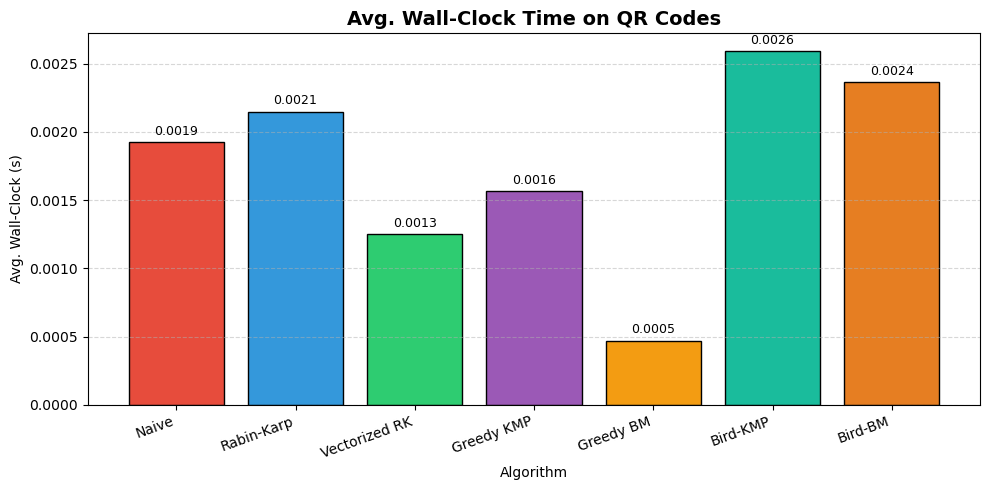

In [26]:
if not df_qr.empty:
    agg_qr_time = (df_qr.groupby('algorithm')['wall_sec']
                   .mean()
                   .reindex(list(ALGORITHMS.keys()))
                   .reset_index())
    agg_qr_time.columns = ['algorithm', 'avg_wall_sec']

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [algo_colors[a] for a in agg_qr_time['algorithm']]
    bars = ax.bar(agg_qr_time['algorithm'], agg_qr_time['avg_wall_sec'], color=colors, edgecolor='black')
    ax.set_title('Avg. Wall-Clock Time on QR Codes', fontsize=14, fontweight='bold')
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Avg. Wall-Clock (s)')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    plt.xticks(rotation=20, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('qr_wallclock.png', dpi=150)
    plt.show()
else:
    print('No QR data to plot.')

---
## Part 3 — Contrived Cases
All-1s text with a 3×3 top part 1's bottom part 0's (to trigger greedy algorithms) placed in the **bottom-right corner** (last 3 rows & last 3 columns).
Pattern: 3×3 block of all 0s.
Text sizes mirror the random ablation.

In [27]:
CONTRIVED_PATTERN = np.array([[1,1,1],[0,0,0],[0,0,0]], dtype=np.int8)

print('Contrived pattern (3×3 zeros with 1 on top):')
print(CONTRIVED_PATTERN)

Contrived pattern (3×3 zeros with 1 on top):
[[1 1 1]
 [0 0 0]
 [0 0 0]]


In [28]:
def make_contrived_text(size: int) -> np.ndarray:
    """All-1s array with a 3×3 block of 0s in the bottom-right corner."""
    arr = np.ones((size, size), dtype=np.int8)
    arr[-3:, -3:] = 0
    return arr

contrived_rows = []

for txt_size in TEXT_SIZES:
    if txt_size < 3:
        continue
    text_c = make_contrived_text(txt_size)
    res = run_all(text_c, CONTRIVED_PATTERN)
    extra = {'text_size': txt_size, 'pattern_size': 3, 'case': 'contrived'}
    contrived_rows.extend(results_to_rows(res, extra))
    print(f'  text_size={txt_size} done. expected match at ({txt_size-3}, {txt_size-3}).')

df_contrived = pd.DataFrame(contrived_rows)
df_contrived.to_csv('results_contrived.csv', index=False)
print(f'\nContrived section complete. Shape: {df_contrived.shape}')
df_contrived

  text_size=25 done. expected match at (22, 22).
  text_size=50 done. expected match at (47, 47).
  text_size=100 done. expected match at (97, 97).
  text_size=200 done. expected match at (197, 197).
  text_size=500 done. expected match at (497, 497).
  text_size=1000 done. expected match at (997, 997).
  text_size=2000 done. expected match at (1997, 1997).

Contrived section complete. Shape: (49, 7)


,algorithm,comparisons,match,wall_sec,text_size,pattern_size,case
0,Naive,2029,"(21, 22)",0.001622,25,3,contrived
1,Rabin-Karp,537,"(21, 22)",0.000964,25,3,contrived
2,Vectorized RK,515,"(21, 22)",0.000900,25,3,contrived
3,Greedy KMP,1107,"(21, 22)",0.000938,25,3,contrived
4,Greedy BM,2029,"(21, 22)",0.001596,25,3,contrived
5,Bird-KMP,552,"(21, 22)",0.000920,25,3,contrived
6,Bird-BM,181,"(21, 22)",0.000927,25,3,contrived
7,Naive,9029,"(46, 47)",0.007652,50,3,contrived
8,Rabin-Karp,2312,"(46, 47)",0.003858,50,3,contrived
9,Vectorized RK,2265,"(46, 47)",0.001884,50,3,contrived


### 3a — Comparisons vs Text Size (Contrived Worst-Case)

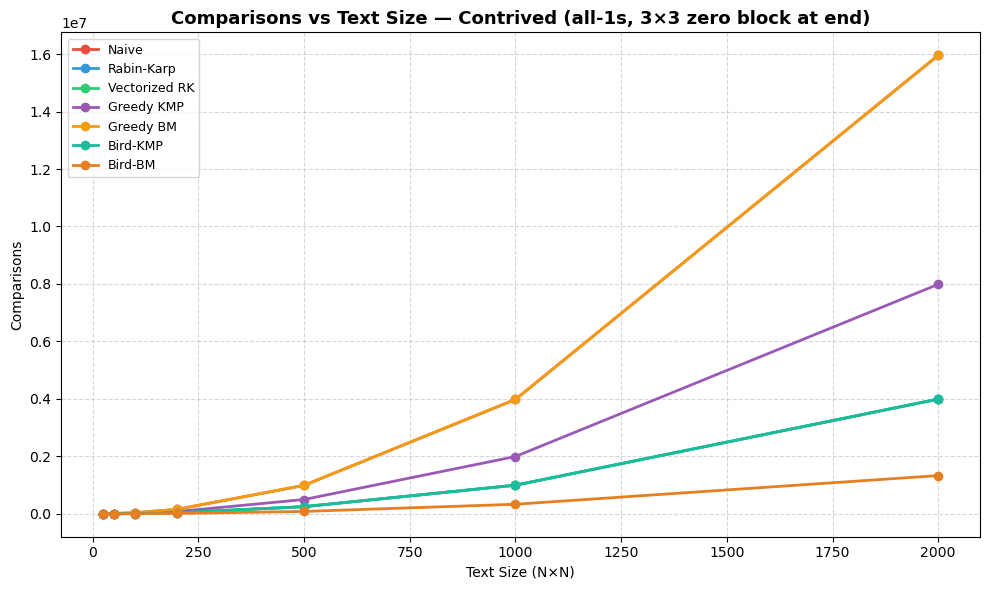

Saved: contrived_comparisons_vs_textsize.png


In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo in ALGORITHMS:
    sub = df_contrived[df_contrived['algorithm'] == algo].sort_values('text_size')
    ax.plot(sub['text_size'], sub['comparisons'],
            marker='o', label=algo, color=algo_colors[algo], linewidth=2)

ax.set_title('Comparisons vs Text Size — Contrived (all-1s, 3×3 zero block at end)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Text Size (N×N)')
ax.set_ylabel('Comparisons')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('contrived_comparisons_vs_textsize.png', dpi=150)

plt.show()
print('Saved: contrived_comparisons_vs_textsize.png')

### 3b — Wall-Clock Time (Contrived)

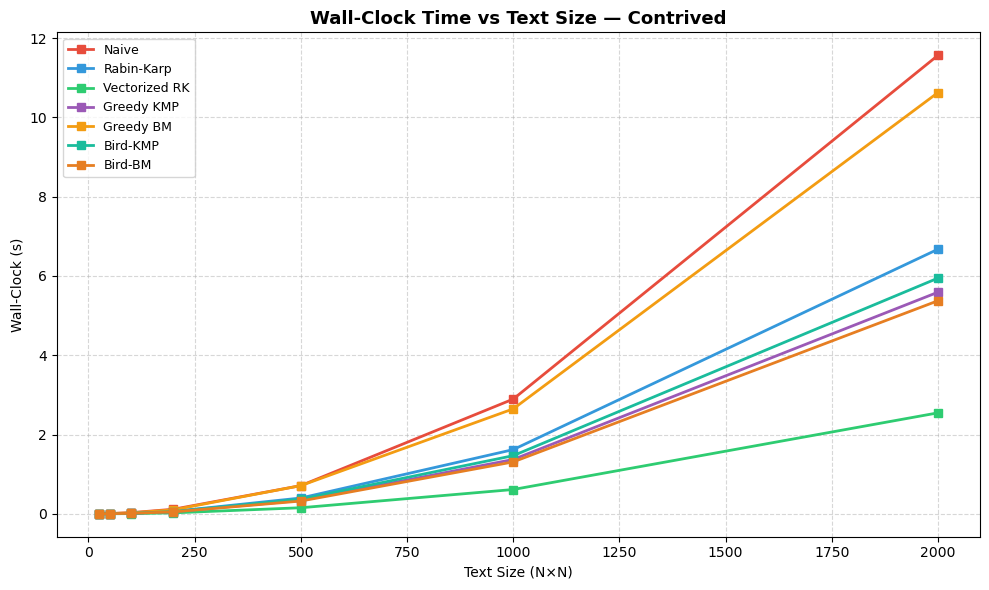

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo in ALGORITHMS:
    sub = df_contrived[df_contrived['algorithm'] == algo].sort_values('text_size')
    ax.plot(sub['text_size'], sub['wall_sec'],
            marker='s', label=algo, color=algo_colors[algo], linewidth=2)

ax.set_title('Wall-Clock Time vs Text Size — Contrived', fontsize=13, fontweight='bold')
ax.set_xlabel('Text Size (N×N)')
ax.set_ylabel('Wall-Clock (s)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('contrived_wallclock.png', dpi=150)
plt.show()

---
## Summary Table — All Sections

In [31]:
# ── Random: overall average per algorithm
s_random = (df_random
            .groupby('algorithm')['comparisons']
            .mean()
            .rename('random_avg_comparisons'))

# ── QR: overall average per algorithm
if not df_qr.empty:
    s_qr = (df_qr
            .groupby('algorithm')['comparisons']
            .mean()
            .rename('qr_avg_comparisons'))
else:
    s_qr = pd.Series(dtype=float, name='qr_avg_comparisons')

# ── Contrived: overall average per algorithm
s_contrived = (df_contrived
               .groupby('algorithm')['comparisons']
               .mean()
               .rename('contrived_avg_comparisons'))

summary = pd.concat([s_random, s_qr, s_contrived], axis=1).round(1)
summary.index.name = 'algorithm'
summary = summary.reindex(list(ALGORITHMS.keys()))
print('=== Summary: Average Comparisons per Section ===')
print(summary.to_string())
summary.to_csv('results_summary.csv')
print('\nSaved: results_summary.csv')

=== Summary: Average Comparisons per Section ===
               random_avg_comparisons  qr_avg_comparisons  contrived_avg_comparisons
algorithm                                                                           
Naive                        753131.0              2184.2                  3019314.7
Rabin-Karp                   750996.4              1148.9                   755387.0
Vectorized RK                750996.4              1148.9                   754836.4
Greedy KMP                  1508161.4              3030.6                  1511864.1
Greedy BM                   1189064.7               710.0                  3019314.7
Bird-KMP                     754329.0              1294.6                   755930.6
Bird-BM                      204743.7               263.6                   251666.7

Saved: results_summary.csv


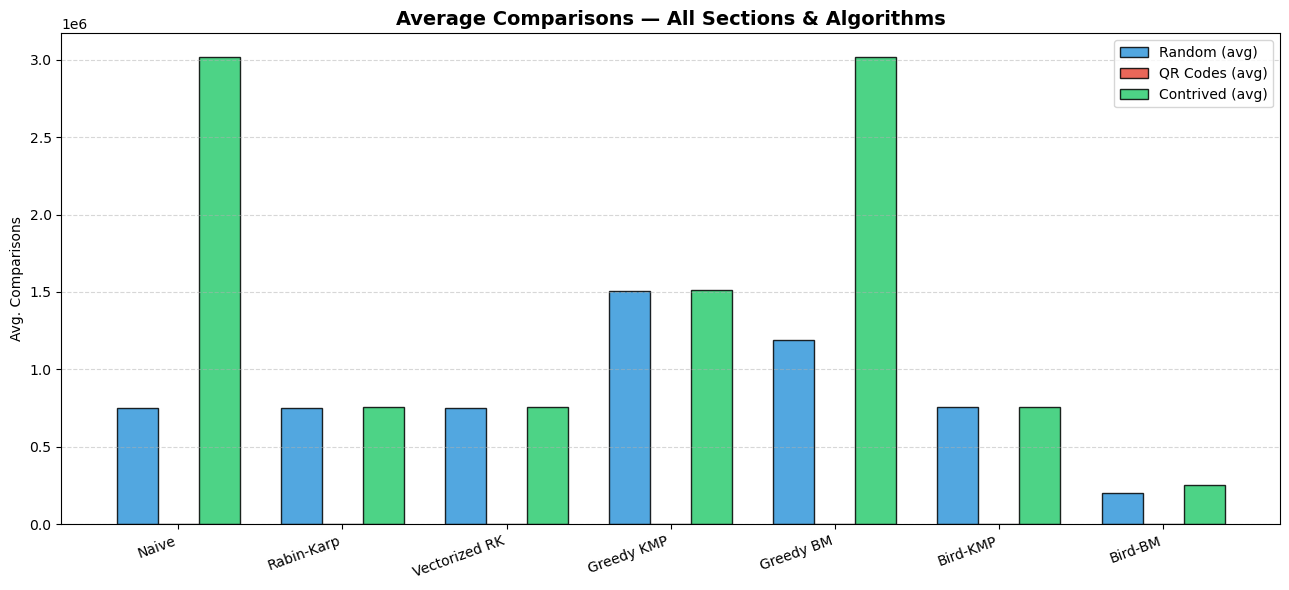

Saved: summary_all_sections.png


In [32]:
# Side-by-side bar chart comparing all three sections
cols_present = [c for c in ['random_avg_comparisons', 'qr_avg_comparisons', 'contrived_avg_comparisons']
                if c in summary.columns and summary[c].notna().any()]

x = np.arange(len(summary))
width = 0.25
section_colors = ['#3498db', '#e74c3c', '#2ecc71']
section_labels = ['Random (avg)', 'QR Codes (avg)', 'Contrived (avg)']

fig, ax = plt.subplots(figsize=(13, 6))
for k, (col, color, label) in enumerate(zip(cols_present, section_colors, section_labels)):
    vals = summary[col].fillna(0).values
    offset = (k - len(cols_present) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='black')

ax.set_title('Average Comparisons — All Sections & Algorithms', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylabel('Avg. Comparisons')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('summary_all_sections.png', dpi=150)
plt.show()
print('Saved: summary_all_sections.png')

Text shape   : (10000, 10000)
Pattern shape: (13, 13)
Guaranteed match at: (9987, 9987)

Running Naive... comps=199,556,580  match=(9987, 9987)  (174.613s)
Running Greedy KMP... comps=249,689,122  match=(9987, 9987)  (135.337s)
Running Greedy BM... comps=16,756,456  match=(9987, 9987)  (13.019s)
Running Bird-KMP... comps=99,891,864  match=(9987, 9987)  (506.051s)
Running Bird-BM... comps=7,682,641  match=(9987, 9987)  (464.731s)

Saved: results_head_to_head.csv


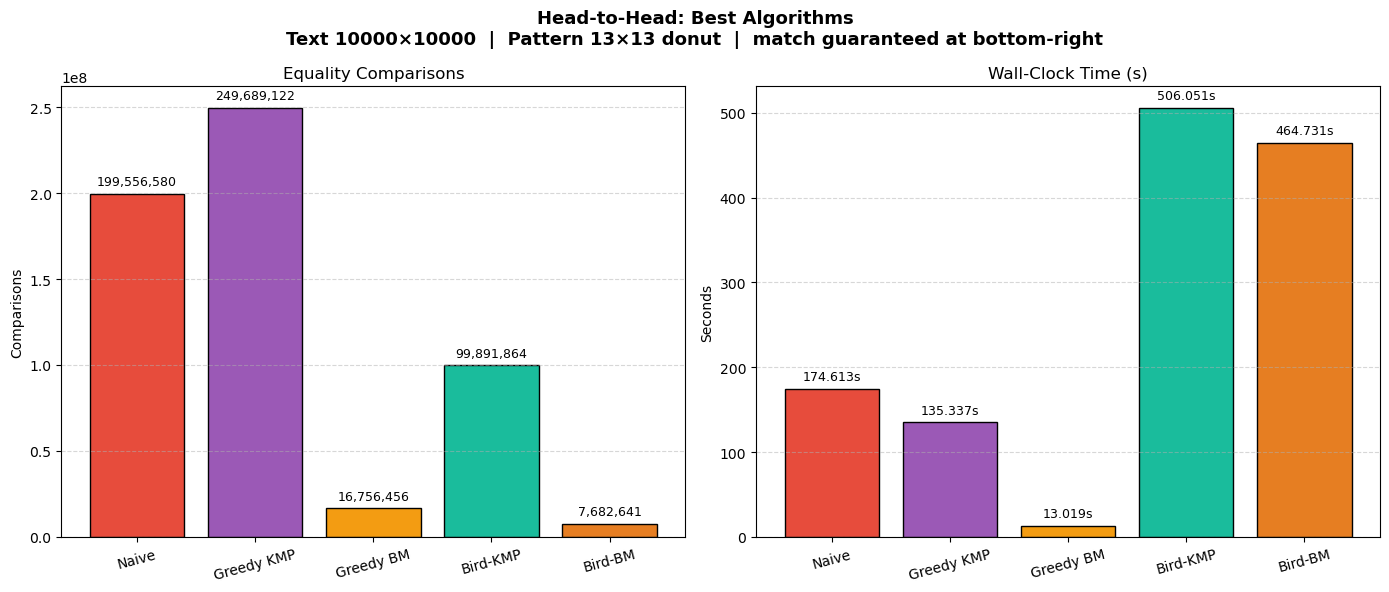

Saved: head_to_head.png


In [33]:
# ── Final Cell: Head-to-Head on Maximum Input ──────────────────────────────
# Algorithms: Naive, Greedy-BM, Greedy-KMP, Bird-BM, Bird-KMP
# Text: 10000×10000 donut  |  Pattern: 25×25 donut, guaranteed at bottom-right

BEST_ALGOS = {
    'Naive':      naive_search,
    'Greedy KMP': greedy_kmp_search,
    'Greedy BM':  greedy_bm_search,
    'Bird-KMP':   bird_kmp,
    'Bird-BM':    bird_bm,
}

BEST_COLORS = {
    'Naive':      '#e74c3c',
    'Greedy KMP': '#9b59b6',
    'Greedy BM':  '#f39c12',
    'Bird-KMP':   '#1abc9c',
    'Bird-BM':    '#e67e22',
}

TEXT_N    = 10_000
PAT_N     = 13

# Build text: donut base, then stamp the 25×25 donut pattern at bottom-right
big_text    = make_random_pattern(TEXT_N, np.random.default_rng(2)).astype(np.int8)
big_pattern = make_donut(PAT_N).astype(np.int8)
big_text[-PAT_N:, -PAT_N:] = big_pattern          # guarantee a match

print(f'Text shape   : {big_text.shape}')
print(f'Pattern shape: {big_pattern.shape}')
print(f'Guaranteed match at: ({TEXT_N - PAT_N}, {TEXT_N - PAT_N})')
print()

head_to_head_rows = []

for name, fn in BEST_ALGOS.items():
    print(f'Running {name}...', end=' ', flush=True)
    t0   = time.perf_counter()
    comp, pos = fn(big_text.copy(), big_pattern.copy())
    wall = time.perf_counter() - t0
    head_to_head_rows.append({'algorithm': name, 'comparisons': comp,
                              'match': pos, 'wall_sec': round(wall, 4)})
    print(f'comps={comp:,}  match={pos}  ({wall:.3f}s)')

df_h2h = pd.DataFrame(head_to_head_rows)
df_h2h.to_csv('results_head_to_head.csv', index=False)
print('\nSaved: results_head_to_head.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Head-to-Head: Best Algorithms\nText {TEXT_N}×{TEXT_N}  |  Pattern {PAT_N}×{PAT_N} donut  |  match guaranteed at bottom-right',
             fontsize=13, fontweight='bold')

# Comparisons bar
colors = [BEST_COLORS[a] for a in df_h2h['algorithm']]
bars = axes[0].bar(df_h2h['algorithm'], df_h2h['comparisons'], color=colors, edgecolor='black')
axes[0].set_title('Equality Comparisons', fontsize=12)
axes[0].set_ylabel('Comparisons')
axes[0].bar_label(bars, fmt=lambda v: f'{int(v):,}', padding=4, fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=15)

# Wall-clock bar
bars2 = axes[1].bar(df_h2h['algorithm'], df_h2h['wall_sec'], color=colors, edgecolor='black')
axes[1].set_title('Wall-Clock Time (s)', fontsize=12)
axes[1].set_ylabel('Seconds')
axes[1].bar_label(bars2, fmt=lambda v: f'{v:.3f}s', padding=4, fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('head_to_head.png', dpi=150)
plt.show()
print('Saved: head_to_head.png')